In [62]:
# importando libs
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [63]:
df = pd.read_csv("consolidado_filtrado_nomes_descritivos.csv", encoding="utf-8-sig")

In [64]:
df.columns

Index(['Ano', 'UF', 'Mes', 'CAPITAL', 'Cor ou raça', 'Escolaridade',
       'Este domicílio é', 'Na semana passada teve dificuldade para respirar?',
       'Na semana passada teve dor de cabeça?',
       'Na semana passada teve dor de garganta?',
       'Na semana passada teve febre?',
       'Na semana passada teve perda de cheiro ou sabor?',
       'Na semana passada teve tosse?',
       'Número da faixa do rendimento/retirada em dinheiro',
       'Qual é a principal atividade do local ou empresa em que você trabalha?',
       'Qual o principal motivo deste afastamento temporário?',
       'Quem respondeu ao questionário?',
       'Rendimento de pensão alimentícia, doação ou mesada em dinheiro de pessoa que não morava no domicílio',
       'Rendimentos de Programa Bolsa Família', 'Sexo',
       'Tem carteira de trabalho assinada ou é funcionário público estatutário?',
       'Rendimento de aposentadoria, pensão, BPC ou outro programa de transferência de renda',
       'Recebeu algum 

In [65]:
df.head()

,Ano,UF,Mes,CAPITAL,Cor ou raça,Escolaridade,Este domicílio é,Na semana passada teve dificuldade para respirar?,Na semana passada teve dor de cabeça?,Na semana passada teve dor de garganta?,...,Qual é a principal atividade do local ou empresa em que você trabalha?,Qual o principal motivo deste afastamento temporário?,Quem respondeu ao questionário?,"Rendimento de pensão alimentícia, doação ou mesada em dinheiro de pessoa que não morava no domicílio",Rendimentos de Programa Bolsa Família,Sexo,Tem carteira de trabalho assinada ou é funcionário público estatutário?,"Rendimento de aposentadoria, pensão, BPC ou outro programa de transferência de renda",Recebeu algum auxílio emergencial?,Tem mais de um trabalho
0,2020,11,Junho,11.0,4,5,1,2,2,2,...,6.0,NaN,1,2,2,1,1.0,35.0,1,2.0
1,2020,11,Junho,11.0,4,7,1,2,2,2,...,22.0,1.0,1,2,2,2,NaN,34.0,1,2.0
2,2020,11,Junho,11.0,4,2,1,2,2,2,...,NaN,NaN,1,2,2,1,NaN,NaN,1,NaN
3,2020,11,Junho,11.0,4,2,1,2,2,2,...,NaN,NaN,1,2,2,1,NaN,NaN,1,NaN
4,2020,11,Junho,11.0,1,2,1,2,2,2,...,NaN,NaN,1,2,2,2,NaN,NaN,2,NaN


In [66]:
map_motivo = {
    1: "Quarentena, isolamento ou férias coletivas",
    2: "Férias, folga ou jornada de trabalho variável",
    3: "Licença maternidade ou paternidade",
    4: "Licença remunerada",
    5: "Outro tipo de licença remunerada (estudo, casamento, etc.)",
    6: "Afastamento do próprio negócio/empresa sem remuneração",
    7: "Fatores ocasionais",
    8: "Outro motivo"
}

map_Sexo = {
    1: "Homem",
    2: "Mulher"
}

In [67]:
# Converte para inteiro (descarta decimais)
df['Qual o principal motivo deste afastamento temporário?'] = pd.to_numeric(df['Qual o principal motivo deste afastamento temporário?'], errors='coerce').astype('Int64')
df['Sexo'] = pd.to_numeric(df['Sexo'], errors='coerce').astype('Int64')

# Agora aplique o mapeamento normalmente
df['Motivo_desc'] = df['Qual o principal motivo deste afastamento temporário?'].map(map_motivo)
df['Sexo_desc'] = df['Sexo'].map(map_Sexo)

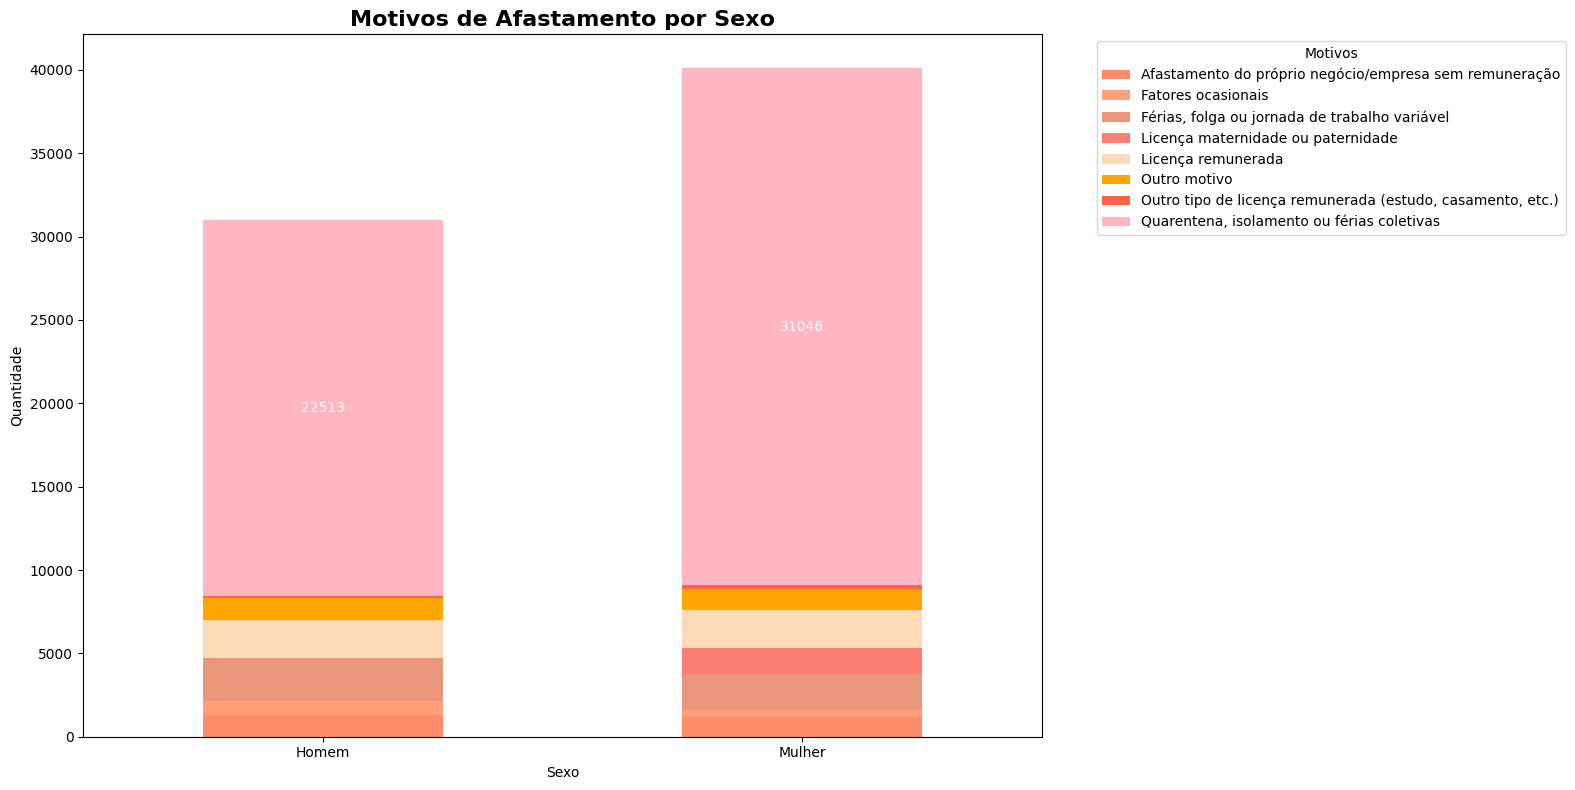

In [68]:
# Garante que as colunas estão como números antes do mapeamento
df['Qual o principal motivo deste afastamento temporário?'] = pd.to_numeric(df['Qual o principal motivo deste afastamento temporário?'], errors='coerce')
df['Sexo'] = pd.to_numeric(df['Sexo'], errors='coerce')

# Aplica os mapas para transformar os códigos em nomes descritivos
df['Motivo_desc'] = df['Qual o principal motivo deste afastamento temporário?'].map(map_motivo)
df['Sexo'] = df['Sexo'].map(map_Sexo)

# Remove linhas com valores nulos após o mapeamento
df_filtrado = df.dropna(subset=['Motivo_desc', 'Sexo'])

# Verifique se o DataFrame filtrado não está vazio
if df_filtrado.empty:
    print("Nenhum dado válido para plotar. Verifique os valores das colunas e o mapeamento.")
else:
    # Agrupa por Sexo e Motivos, conta ocorrências
    df_group = df_filtrado.groupby(['Sexo', 'Motivo_desc']).size().unstack(fill_value=0)

    # Plota barras empilhadas
    cores = ["#FF8C69", "#FFA07A", "#E9967A", "#FA8072", "#FFDAB9", "#FFA500", "#FF6347", "#FFB6C1"]
    ax = df_group.plot(kind='bar', stacked=True, figsize=(16, 8), color=cores)

    plt.ylabel("Quantidade")
    plt.title("Motivos de Afastamento por Sexo", fontsize=16, weight="bold")
    plt.legend(title="Motivos", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.xticks(rotation=0)  # Mantém os rótulos do eixo X na horizontal
    plt.tight_layout()

    # Adiciona os valores nas barras empilhadas
    for idx, row in enumerate(df_group.values):
        y_offset = 0
        for i, v in enumerate(row):
            if v > 2700:  # só mostra se o valor for maior que 50
                ax.text(idx, y_offset + v / 2, str(v), ha='center', va='center', fontsize=10, color='white')
            y_offset += v
    plt.show()

In [69]:
df.columns

Index(['Ano', 'UF', 'Mes', 'CAPITAL', 'Cor ou raça', 'Escolaridade',
       'Este domicílio é', 'Na semana passada teve dificuldade para respirar?',
       'Na semana passada teve dor de cabeça?',
       'Na semana passada teve dor de garganta?',
       'Na semana passada teve febre?',
       'Na semana passada teve perda de cheiro ou sabor?',
       'Na semana passada teve tosse?',
       'Número da faixa do rendimento/retirada em dinheiro',
       'Qual é a principal atividade do local ou empresa em que você trabalha?',
       'Qual o principal motivo deste afastamento temporário?',
       'Quem respondeu ao questionário?',
       'Rendimento de pensão alimentícia, doação ou mesada em dinheiro de pessoa que não morava no domicílio',
       'Rendimentos de Programa Bolsa Família', 'Sexo',
       'Tem carteira de trabalho assinada ou é funcionário público estatutário?',
       'Rendimento de aposentadoria, pensão, BPC ou outro programa de transferência de renda',
       'Recebeu algum 

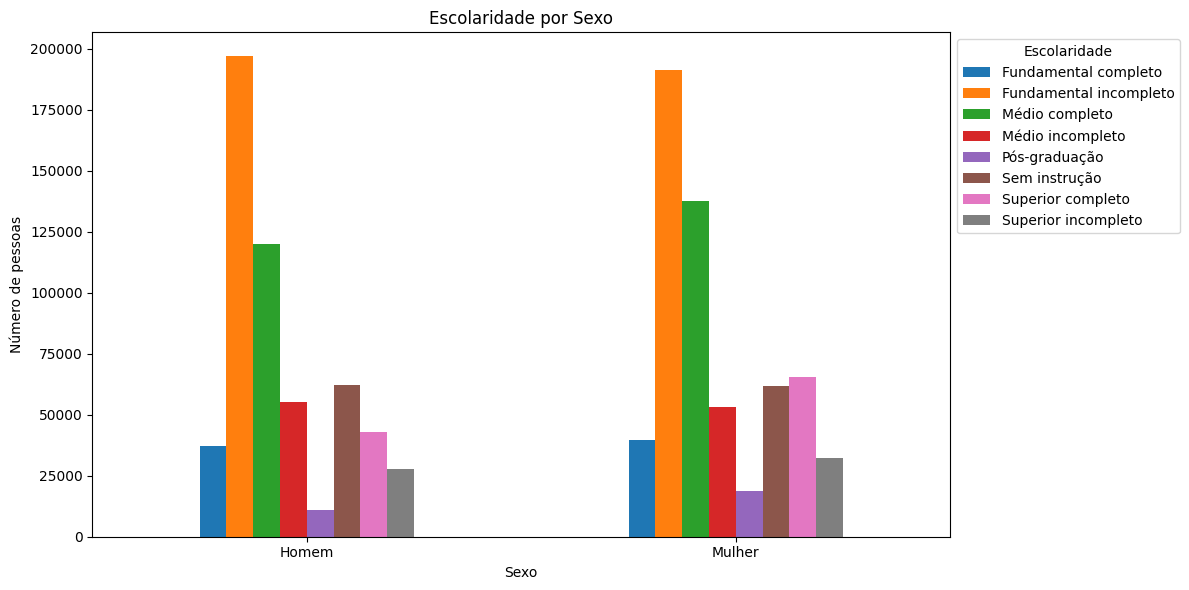

In [70]:
# Dicionários de mapeamento
map_sexo = {1: "Homem", 2: "Mulher"}
map_escolaridade = {
    1: "Sem instrução",
    2: "Fundamental incompleto",
    3: "Fundamental completo",
    4: "Médio incompleto",
    5: "Médio completo",
    6: "Superior incompleto",
    7: "Superior completo",
    8: "Pós-graduação"
}

# Aplicar os mapeamentos só na visualização (sem alterar df original)
(df.assign(
    Sexo=df['Sexo'].replace(map_sexo),
    Escolaridade=df['Escolaridade'].replace(map_escolaridade)
 )
 .groupby(['Sexo', 'Escolaridade'])
 .size()
 .unstack()
 .plot(kind='bar', figsize=(12,6))
)

plt.title('Escolaridade por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Número de pessoas')
plt.xticks(rotation=0)
plt.legend(title='Escolaridade', loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()


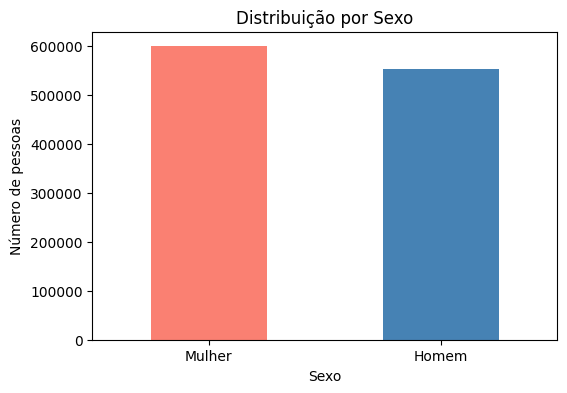

In [71]:
# Dicionário de mapeamento
map_sexo = {1: "Homem", 2: "Mulher"}

# Plotar usando o mapeamento sem alterar o df original
(df['Sexo'].replace(map_sexo)
   .value_counts()
   .plot(kind='bar', figsize=(6,4), color=['salmon', 'steelblue'])
)

plt.title('Distribuição por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Número de pessoas')
plt.xticks(rotation=0)
plt.show()


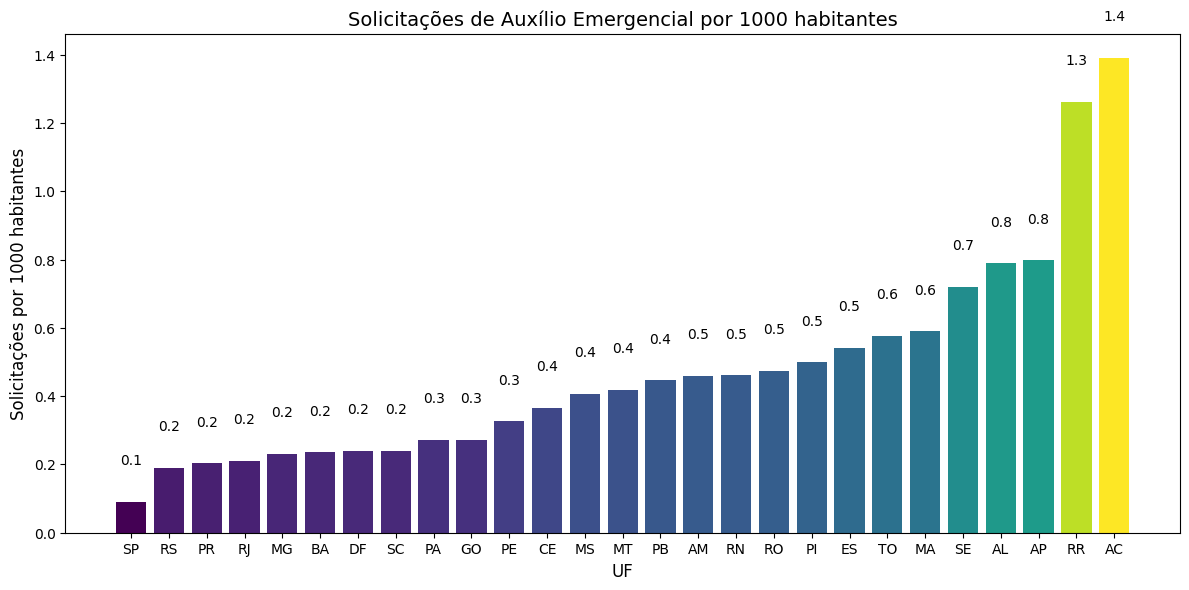

In [72]:

# --- Ler população direto do IBGE ---
url = "https://ftp.ibge.gov.br/Estimativas_de_Populacao/Estimativas_2025/estimativa_dou_2025.xls"
pop_df = pd.read_excel(url, sheet_name='BRASIL E UFs', skiprows=2, usecols="A:B", names=["UF", "População"])

# Filtra apenas os estados
estados = ["Rondônia","Acre","Amazonas","Roraima","Pará","Amapá","Tocantins",
           "Maranhão","Piauí","Ceará","Rio Grande do Norte","Paraíba","Pernambuco","Alagoas","Sergipe","Bahia",
           "Minas Gerais","Espírito Santo","Rio de Janeiro","São Paulo",
           "Paraná","Santa Catarina","Rio Grande do Sul",
           "Mato Grosso do Sul","Mato Grosso","Goiás","Distrito Federal"]
pop_df = pop_df[pop_df['UF'].isin(estados)]
pop_df['População'] = pop_df['População'].astype(str).str.replace('.', '').astype(int)

# Mapear nomes para siglas
pop_df['UF'] = pop_df['UF'].map({
    "Rondônia":"RO","Acre":"AC","Amazonas":"AM","Roraima":"RR","Pará":"PA","Amapá":"AP","Tocantins":"TO",
    "Maranhão":"MA","Piauí":"PI","Ceará":"CE","Rio Grande do Norte":"RN","Paraíba":"PB","Pernambuco":"PE",
    "Alagoas":"AL","Sergipe":"SE","Bahia":"BA","Minas Gerais":"MG","Espírito Santo":"ES","Rio de Janeiro":"RJ",
    "São Paulo":"SP","Paraná":"PR","Santa Catarina":"SC","Rio Grande do Sul":"RS","Mato Grosso do Sul":"MS",
    "Mato Grosso":"MT","Goiás":"GO","Distrito Federal":"DF"
})

# --- Mapear códigos UF da sua base para siglas ---
map_uf = {
    11: "RO", 12: "AC", 13: "AM", 14: "RR", 15: "PA", 16: "AP", 17: "TO",
    21: "MA", 22: "PI", 23: "CE", 24: "RN", 25: "PB", 26: "PE", 27: "AL",
    28: "SE", 29: "BA", 31: "MG", 32: "ES", 33: "RJ", 35: "SP", 41: "PR",
    42: "SC", 43: "RS", 50: "MS", 51: "MT", 52: "GO", 53: "DF"
}
df['UF'] = df['UF'].replace(map_uf)

# Mapear valores de auxílio
map_auxilio = {1: "Sim", 2: "Não"}
df['Recebeu algum auxílio emergencial?'] = df['Recebeu algum auxílio emergencial?'].replace(map_auxilio)

# --- Conta quantos "Sim" por UF ---
auxilio_por_uf = df.groupby('UF')['Recebeu algum auxílio emergencial?'].apply(lambda x: (x == 'Sim').sum()).reset_index()
auxilio_por_uf.rename(columns={'Recebeu algum auxílio emergencial?': 'Solicitacoes'}, inplace=True)

# --- Une com a população ---
df_final = auxilio_por_uf.merge(pop_df, on='UF', how='left')

# Calcula número de solicitações por 1000 habitantes
df_final['Solicitacoes_per_1000'] = df_final['Solicitacoes'] / df_final['População'] * 1000

# Ordena do menor para o maior per capita
df_final = df_final.sort_values('Solicitacoes_per_1000')

# Define cores graduais (mais escuro = mais solicitações per capita)
norm = mcolors.Normalize(vmin=df_final['Solicitacoes_per_1000'].min(), vmax=df_final['Solicitacoes_per_1000'].max())
colors = cm.viridis(norm(df_final['Solicitacoes_per_1000']))

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(12,6))
bars = ax.bar(df_final['UF'], df_final['Solicitacoes_per_1000'], color=colors)

plt.title('Solicitações de Auxílio Emergencial por 1000 habitantes', fontsize=14)
plt.xlabel('UF', fontsize=12)
plt.ylabel('Solicitações por 1000 habitantes', fontsize=12)

# Adiciona os valores sobre as barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.1, f'{height:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


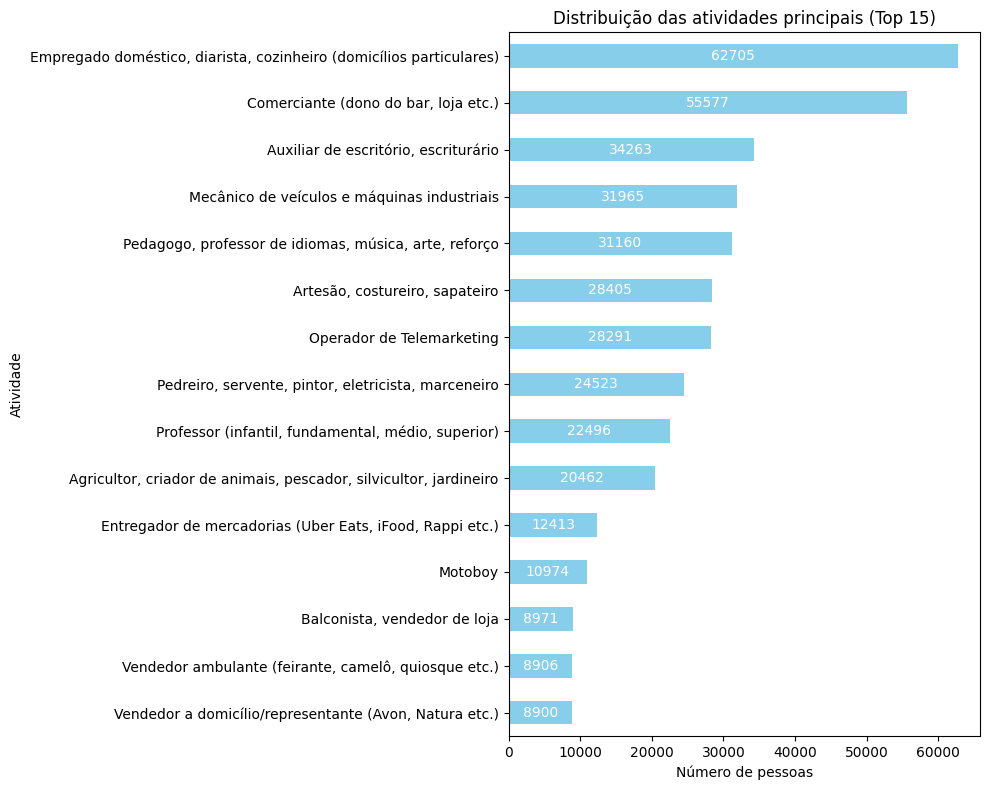

In [73]:


map_atividade = {
    1: "Empregado doméstico, diarista, cozinheiro (domicílios particulares)",
    2: "Faxineiro, auxiliar de limpeza (empresa pública/privada)",
    3: "Auxiliar de escritório, escriturário",
    4: "Secretária, recepcionista",
    5: "Operador de Telemarketing",
    6: "Comerciante (dono do bar, loja etc.)",
    7: "Balconista, vendedor de loja",
    8: "Vendedor a domicílio/representante (Avon, Natura etc.)",
    9: "Vendedor ambulante (feirante, camelô, quiosque etc.)",
    10: "Cozinheiro e garçom (restaurantes, empresas)",
    11: "Padeiro, açougueiro e doceiro",
    12: "Agricultor, criador de animais, pescador, silvicultor, jardineiro",
    13: "Auxiliar da agropecuária (colhedor, boia fria etc.)",
    14: "Motorista (aplicativo, táxi, van, ônibus etc.)",
    15: "Motorista de caminhão (caminhoneiro)",
    16: "Motoboy",
    17: "Entregador de mercadorias (Uber Eats, iFood, Rappi etc.)",
    18: "Pedreiro, servente, pintor, eletricista, marceneiro",
    19: "Mecânico de veículos e máquinas industriais",
    20: "Artesão, costureiro, sapateiro",
    21: "Cabeleireiro, manicure e afins",
    22: "Operador de máquinas, montador na indústria",
    23: "Auxiliar de produção, carga e descarga",
    24: "Professor (infantil, fundamental, médio, superior)",
    25: "Pedagogo, professor de idiomas, música, arte, reforço",
    26: "Profissional de saúde (nível superior)",
    27: "Profissional de saúde (nível médio/técnico)",
    28: "Cuidador de crianças, doentes, idosos",
    29: "Segurança, vigilante, serviços de proteção",
    30: "Policial civil",
    31: "Porteiro, zelador",
    32: "Artista, religioso (padre, pastor etc.)",
    33: "Diretor, gerente, cargo político/comissionado",
    34: "Outra profissão de nível superior",
    35: "Outro técnico/profissional de nível médio",
    36: "Outros",
    99: "Não aplicável"  # caso apareça como categoria
}

# Criar coluna mapeada
df['Atividade_mapeada'] = df['Qual é a principal atividade do local ou empresa em que você trabalha?'] \
                            .map(map_atividade)

# Capturar o eixo (ax) para poder usar bar_label
ax = df['Atividade_mapeada'].value_counts().head(15).plot(
    kind='barh', figsize=(10,8), color='skyblue'
)

# Adicionar labels nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='center', color='white')

# Ajustes do gráfico
plt.title('Distribuição das atividades principais (Top 15)')
plt.xlabel('Número de pessoas')
plt.ylabel('Atividade')
plt.gca().invert_yaxis()  # deixa o maior no topo
plt.tight_layout()
plt.show()
